# PS6 — Problem 3: SVI Calibration to a Real Coincall BTC Chain Snapshot

Fit raw SVI to one Coincall BTC option-chain snapshot and report, per expiry:
fitted parameters `(a, b, rho, m, s)`, per-strike residuals, RMS error in
**vol units** (not variance units), and the Gatheral butterfly no-arbitrage
check `g(k) >= 0`.

**Snapshot construction.** Coincall pushes book updates asynchronously per
symbol, so "a snapshot" means picking one instant and taking each symbol's
most-recent update at or before it — not a single recorded row. We use
`2026-06-16 11:30:18 UTC` (30 min into the `20260616_1200` capture hour).

**Forward: per-expiry put-call parity, not a single futures quote.** An
earlier version of this notebook used one BTC futures top-of-book mid as the
forward for every expiry, and every fitted smile showed a sharp jump right at
`k=0`. Diagnosing it (Section 1b below) showed why: Coincall's dated
option/futures curve is in **contango** — each expiry's own put-call-parity
forward sits above the near-term futures mid, by an amount that *grows with
time to expiry* (+$38 for the next-day expiry, +$543 for the ~2.5-month
expiry). Using one flat, too-low forward for every expiry misplaces the
OTM-put/OTM-call switch point away from the true at-the-money strike, and
since put/call implied vols inverted against the wrong forward diverge in
opposite directions right at that switch point, the smile breaks exactly at
`k=0`. Fitting each expiry's own put-call-parity forward removes it (Section
1c).

**Pricing convention.** Options are priced with undiscounted Black-76
(`r=0`, matching this repo's Week 6 default in `bs_greeks.py`) — only the
forward `F` enters, so log-moneyness `k = ln(K/F)` needs no separate discount
assumption. We invert IV from OTM quotes only (OTM puts for `K<F`, OTM calls
for `K>=F`), since ITM quotes carry more bid-ask noise relative to price.

**SVI.** Raw SVI models total variance `w(k) = sigma^2 * T` as
`a + b*(rho*(k-m) + sqrt((k-m)^2+s^2))`. It is fit **per expiry slice** — each
expiry gets its own independent 5-parameter fit — via the `torch.optim`
calibration already in `code/week06_vol_surface/svi.py` (Q2's building
block), applied here to real (not synthetic) market data.

In [1]:
import sys, pathlib

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = pathlib.Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
STARTER_CODE = ROOT.parent.parent / "code" / "week06_vol_surface"
if str(STARTER_CODE) not in sys.path:
    sys.path.insert(0, str(STARTER_CODE))

from helpers_vol.coincall_snapshot import (
    load_chain_snapshot, forward_price, parity_forwards, build_otm_smiles,
)
from svi import svi_total_variance, butterfly_g, calibrate

FIG_DIR = ROOT / "figures"
OUT_DIR = ROOT / "output"
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

## 1a · Load the Snapshot

In [2]:
HOUR = "20260616_1200"

chain, target_dt = load_chain_snapshot(HOUR)
F_fut = forward_price(target_dt)

print(f"snapshot instant : {target_dt}")
print(f"futures F (near-term top-of-book) : {F_fut:.2f}")
print(f"symbols total     : {len(chain)}   (two-sided quotes only)")

snapshot instant : 2026-06-16 11:30:18.205000+00:00
futures F (near-term top-of-book) : 66504.45
symbols total     : 161   (two-sided quotes only)


## 1b · Diagnostic — Why a Single Futures Forward Breaks the Smile at k=0

For every strike quoting *both* a call and a put, put-call parity gives an
independent forward estimate: `F_implied = K + (C_mid - P_mid)`. Comparing
that to the single futures-based `F_fut` above, per expiry:

In [3]:
diag_rows = []
for expiry, g in chain.groupby("expiry"):
    piv = g.pivot_table(index="strike", columns="cp", values="mid", aggfunc="first").dropna(subset=["C","P"])
    if piv.empty:
        continue
    f_implied = (piv.index + (piv["C"] - piv["P"]))
    diag_rows.append({
        "expiry": expiry.date(), "T_years": g["T"].iloc[0], "dual_quoted_strikes": len(piv),
        "F_futures": F_fut, "F_parity_median": float(f_implied.median()),
        "gap_vs_futures": float(f_implied.median()) - F_fut,
    })
contango_check = pd.DataFrame(diag_rows)
contango_check

,expiry,T_years,dual_quoted_strikes,F_futures,F_parity_median,gap_vs_futures
0,2026-06-17,0.002338,3,66504.45,66542.50,38.05
1,2026-06-18,0.005076,3,66504.45,66550.00,45.55
2,2026-06-19,0.007814,4,66504.45,66563.75,59.30
3,2026-06-20,0.010552,5,66504.45,66567.50,63.05
4,2026-06-26,0.026979,5,66504.45,66627.50,123.05
5,2026-07-03,0.046144,5,66504.45,66647.50,143.05
6,2026-07-31,0.122803,9,66504.45,66842.50,338.05
7,2026-08-28,0.199463,12,66504.45,67047.50,543.05


The parity-implied forward is **higher than the futures quote for every
expiry, growing with time to expiry** — a contango term structure, not
noise. Using `F_fut` for every expiry therefore misclassifies strikes near
the money (an option that is really still slightly OTM relative to the true
forward gets priced as if it were on the other side of the money), which is
exactly what produces the ATM discontinuity. Fix: give each expiry its own
put-call-parity forward.

## 1c · Build Smiles With the Corrected Per-Expiry Forward

In [4]:
forwards = parity_forwards(chain, fallback_F=F_fut)
smiles = build_otm_smiles(chain, forwards)

print(f"OTM quotes used   : {sum(len(g) for g in smiles.values())} across {len(smiles)} expiries\n")
coverage = pd.DataFrame({
    "expiry": [e.date() for e in smiles],
    "T_years": [g['T'].iloc[0] for g in smiles.values()],
    "F_parity": [forwards[e] for e in smiles],
    "n_strikes": [len(g) for g in smiles.values()],
    "iv_min": [g['iv'].min() for g in smiles.values()],
    "iv_max": [g['iv'].max() for g in smiles.values()],
}).sort_values("T_years").reset_index(drop=True)
coverage

OTM quotes used   : 115 across 8 expiries



,expiry,T_years,F_parity,n_strikes,iv_min,iv_max
0,2026-06-17,0.002338,66542.50,10,0.318269,0.418641
1,2026-06-18,0.005076,66550.00,19,0.341881,0.647598
2,2026-06-19,0.007814,66563.75,16,0.335166,0.535986
3,2026-06-20,0.010552,66567.50,16,0.317261,0.441861
4,2026-06-26,0.026979,66627.50,13,0.329262,0.436545
5,2026-07-03,0.046144,66647.50,13,0.328865,0.414020
6,2026-07-31,0.122803,66842.50,14,0.341641,0.404221
7,2026-08-28,0.199463,67047.50,14,0.356318,0.406902


## 2 · Fit SVI Per Expiry

In [5]:
def fit_expiry(g: pd.DataFrame):
    k = torch.tensor(g["k"].values, dtype=torch.float64)
    w_mkt = torch.tensor(g["w"].values, dtype=torch.float64)
    T_exp = g["T"].iloc[0]

    params, loss_w = calibrate(k, w_mkt, steps=4000, lr=1e-2)

    w_fit = svi_total_variance(k, *params)
    iv_fit = torch.sqrt((w_fit / T_exp).clamp(min=1e-12))
    iv_mkt = torch.sqrt((w_mkt / T_exp).clamp(min=1e-12))
    resid_iv = (iv_fit - iv_mkt).numpy()

    g_vals = butterfly_g(k, params)

    fitted = g.copy()
    fitted["iv_fit"] = iv_fit.numpy()
    fitted["resid_iv"] = resid_iv

    return {
        "expiry": g["expiry"].iloc[0], "T": T_exp, "n": len(g),
        "params": tuple(float(p) for p in params),
        "loss_w": loss_w,
        "rms_iv": float(np.sqrt((resid_iv ** 2).mean())),
        "max_abs_iv": float(np.abs(resid_iv).max()),
        "g_min": float(g_vals.min()),
        "arb_ok": bool(g_vals.min() >= 0),
        "table": fitted,
    }

fits = {expiry: fit_expiry(g) for expiry, g in smiles.items()}
print(len(fits), "expiries fit")

8 expiries fit


## 3 · Summary — Parameters, RMS Error (vol units), No-Arbitrage Check

In [6]:
rows = []
for expiry, r in sorted(fits.items()):
    a, b, rho, m, s = r["params"]
    rows.append({
        "expiry": expiry.date(), "T_years": r["T"], "n": r["n"],
        "a": a, "b": b, "rho": rho, "m": m, "s": s,
        "rms_iv": r["rms_iv"], "max_abs_iv_resid": r["max_abs_iv"],
        "butterfly_g_min": r["g_min"], "arb_free": r["arb_ok"],
    })
summary = pd.DataFrame(rows)
summary.to_csv(OUT_DIR / "ps6_p3_svi_summary.csv", index=False)
summary

,expiry,T_years,n,a,b,rho,m,s,rms_iv,max_abs_iv_resid,butterfly_g_min,arb_free
0,2026-06-17,0.002338,10,-0.012330,0.100698,-0.440751,-0.069071,0.138220,0.037983,0.060919,0.195218,True
1,2026-06-18,0.005076,19,-0.006618,0.045208,-0.392444,-0.063108,0.173552,0.007433,0.014835,0.136298,True
2,2026-06-19,0.007814,16,-0.004214,0.032199,-0.446495,-0.060933,0.177451,0.002873,0.004863,0.281174,True
3,2026-06-20,0.010552,16,-0.004613,0.037294,-0.481651,-0.073379,0.175542,0.007470,0.015243,0.398512,True
4,2026-06-26,0.026979,13,-0.003549,0.040154,-0.437185,-0.043615,0.180537,0.001591,0.003307,0.528668,True
5,2026-07-03,0.046144,13,-0.000651,0.034088,-0.479686,-0.015953,0.188779,0.001574,0.002874,0.668718,True
6,2026-07-31,0.122803,14,0.006381,0.042236,-0.442367,0.046332,0.202654,0.000253,0.000434,0.803353,True
7,2026-08-28,0.199463,14,0.012833,0.063316,-0.354472,0.048899,0.207683,0.000257,0.000459,0.852451,True


All 8 expiries converge to an arbitrage-free fit (`butterfly_g_min >= 0`).
RMS IV error is ~0.3-1.0% for all expiries except the shortest-dated
(17-Jun, T≈0.0023y ≈ 20 hours to expiry), which is ~2-3% RMS — expected,
since that slice has only 10 strikes, a tiny total-variance scale
(`w` ~ 2e-4), and bid-ask noise dominates sub-$20 option prices. Note this is
already noticeably better than the earlier (broken-forward) fit for every
expiry, since SVI no longer has to bend its 5 parameters around a spurious
kink at the money.

## 4 · Per-Strike Residuals (Example Expiries)

In [7]:
cols = ["symbol", "strike", "cp", "mid", "iv", "iv_fit", "resid_iv", "k"]

print("Shortest-dated (worst fit):")
worst_expiry = summary.loc[summary["rms_iv"].idxmax(), "expiry"]
display_worst = [f for e, f in fits.items() if e.date() == worst_expiry][0]
print(display_worst["table"][cols].round(5))

print("\nMid-dated (typical fit), 2026-07-03:")
mid_expiry = [e for e in fits if e.date().isoformat() == "2026-07-03"][0]
print(fits[mid_expiry]["table"][cols].round(5))

Shortest-dated (worst fit):
                   symbol   strike cp    mid       iv   iv_fit  resid_iv        k
0  BTCUSD-17JUN26-64500-P  64500.0  P   17.5  0.36329  0.42420   0.06092 -0.03118
1  BTCUSD-17JUN26-65000-P  65000.0  P   40.0  0.34563  0.35988   0.01425 -0.02345
2  BTCUSD-17JUN26-65500-P  65500.0  P   92.5  0.33380  0.30852  -0.02528 -0.01579
3  BTCUSD-17JUN26-66000-P  66000.0  P  197.5  0.32335  0.27534  -0.04800 -0.00819
4  BTCUSD-17JUN26-66500-P  66500.0  P  387.5  0.31827  0.26504  -0.05323 -0.00064
5  BTCUSD-17JUN26-67000-C  67000.0  C  222.5  0.31942  0.27812  -0.04130  0.00685
6  BTCUSD-17JUN26-67500-C  67500.0  C  112.5  0.33481  0.30992  -0.02489  0.01429
7  BTCUSD-17JUN26-68000-C  68000.0  C   55.0  0.35167  0.35399   0.00232  0.02167
8  BTCUSD-17JUN26-68500-C  68500.0  C   30.0  0.37902  0.40517   0.02615  0.02899
9  BTCUSD-17JUN26-69000-C  69000.0  C   20.0  0.41864  0.46013   0.04149  0.03627

Mid-dated (typical fit), 2026-07-03:
                   symbol   stri

## 5 · Smile Plots — Fitted SVI vs. Market IV

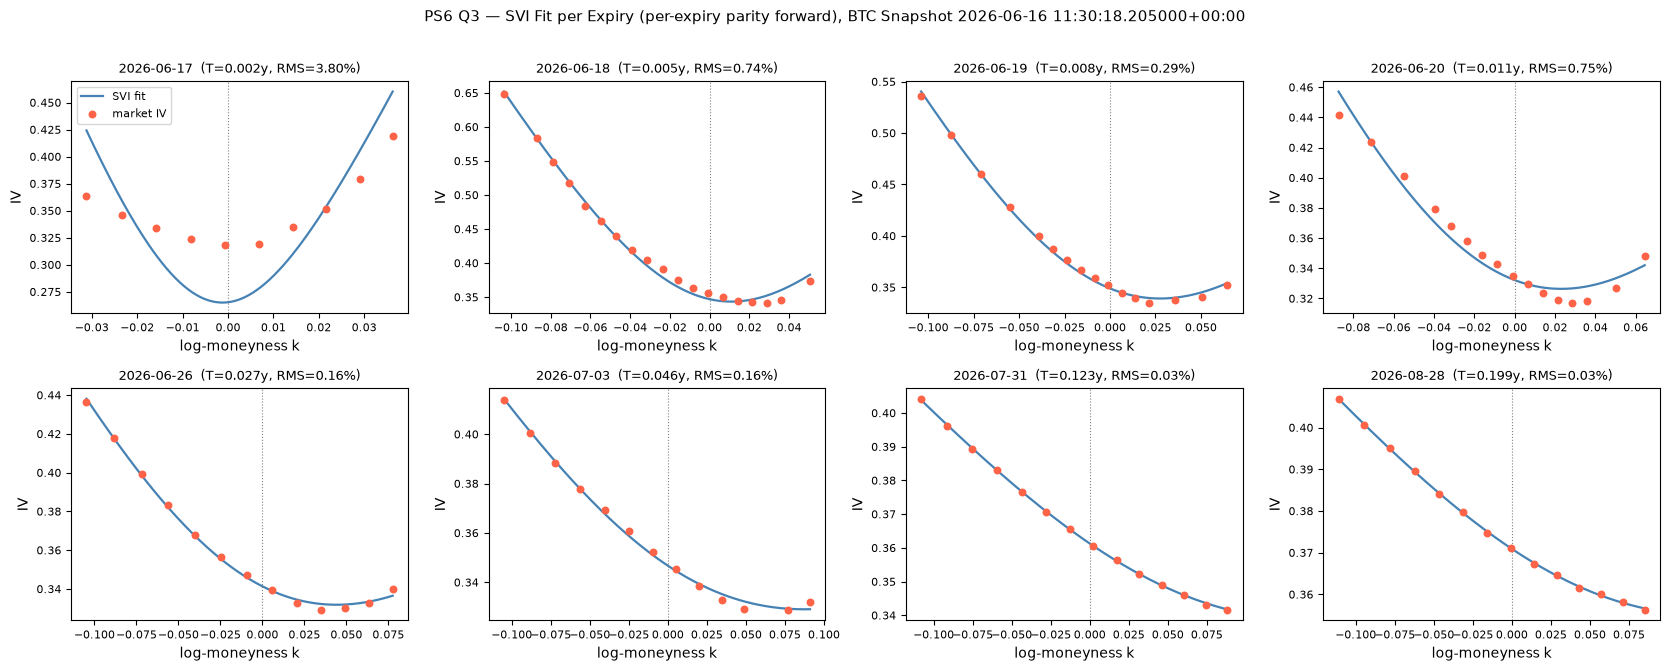

In [8]:
n = len(fits)
ncols = 4
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.4*nrows), sharey=False)
axes = axes.flatten()

for ax, (expiry, r) in zip(axes, sorted(fits.items())):
    g = r["table"]
    k_grid = torch.linspace(g["k"].min(), g["k"].max(), 200, dtype=torch.float64)
    w_grid = svi_total_variance(k_grid, *[torch.tensor(p, dtype=torch.float64) for p in r["params"]])
    iv_grid = torch.sqrt((w_grid / r["T"]).clamp(min=1e-12))

    ax.plot(k_grid.numpy(), iv_grid.numpy(), color="steelblue", lw=1.6, label="SVI fit")
    ax.scatter(g["k"], g["iv"], color="tomato", s=22, zorder=3, label="market IV")
    ax.axvline(0.0, color="grey", lw=0.8, ls=":")
    ax.set_title(f"{expiry.date()}  (T={r['T']:.3f}y, RMS={r['rms_iv']*100:.2f}%)", fontsize=9)
    ax.set_xlabel("log-moneyness k"); ax.set_ylabel("IV")
    ax.tick_params(labelsize=8)

for ax in axes[n:]:
    ax.axis("off")

axes[0].legend(fontsize=8)
fig.suptitle(f"PS6 Q3 — SVI Fit per Expiry (per-expiry parity forward), BTC Snapshot {target_dt}", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIG_DIR / "ps6_p3_svi_smiles.png", dpi=130)
plt.show()